--- Decision Tree ---
Accuracy: 0.77
Tree Depth: 20
Leaves: 176

--- Random Forest ---
Accuracy: 0.79
Number of Estimators: 100
Average Tree Depth: 17.20

--- Cross-validation Results (5-fold) ---
Decision Tree CV Accuracy: 0.78 ± 0.03
Random Forest CV Accuracy: 0.81 ± 0.02


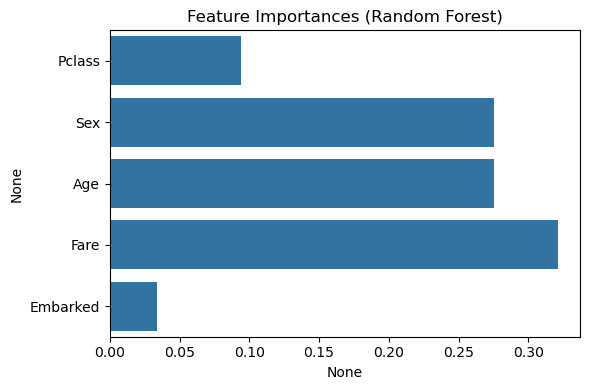

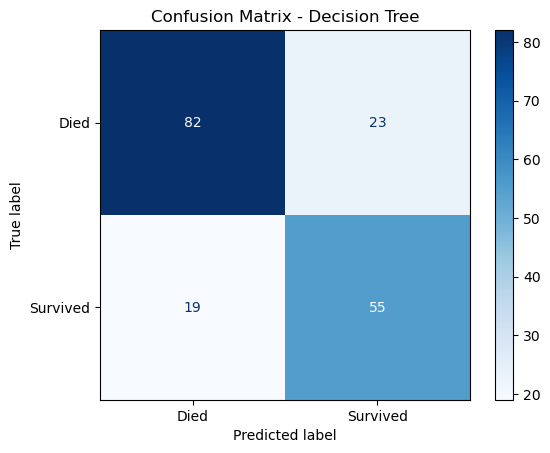

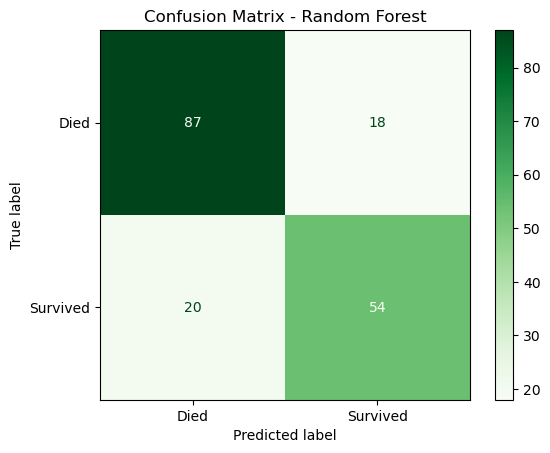

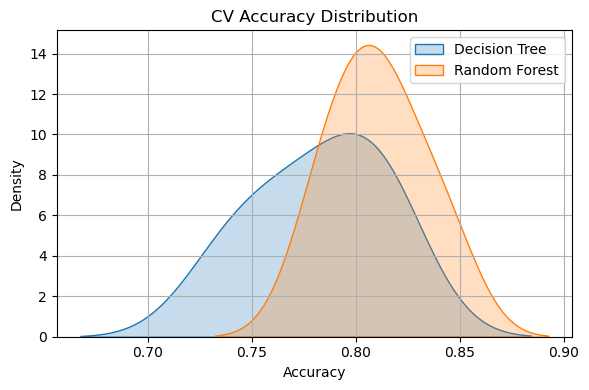

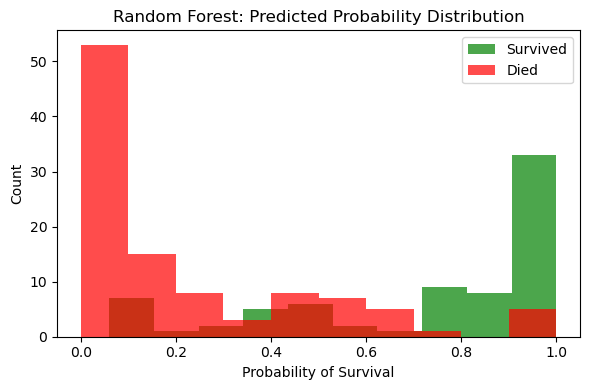

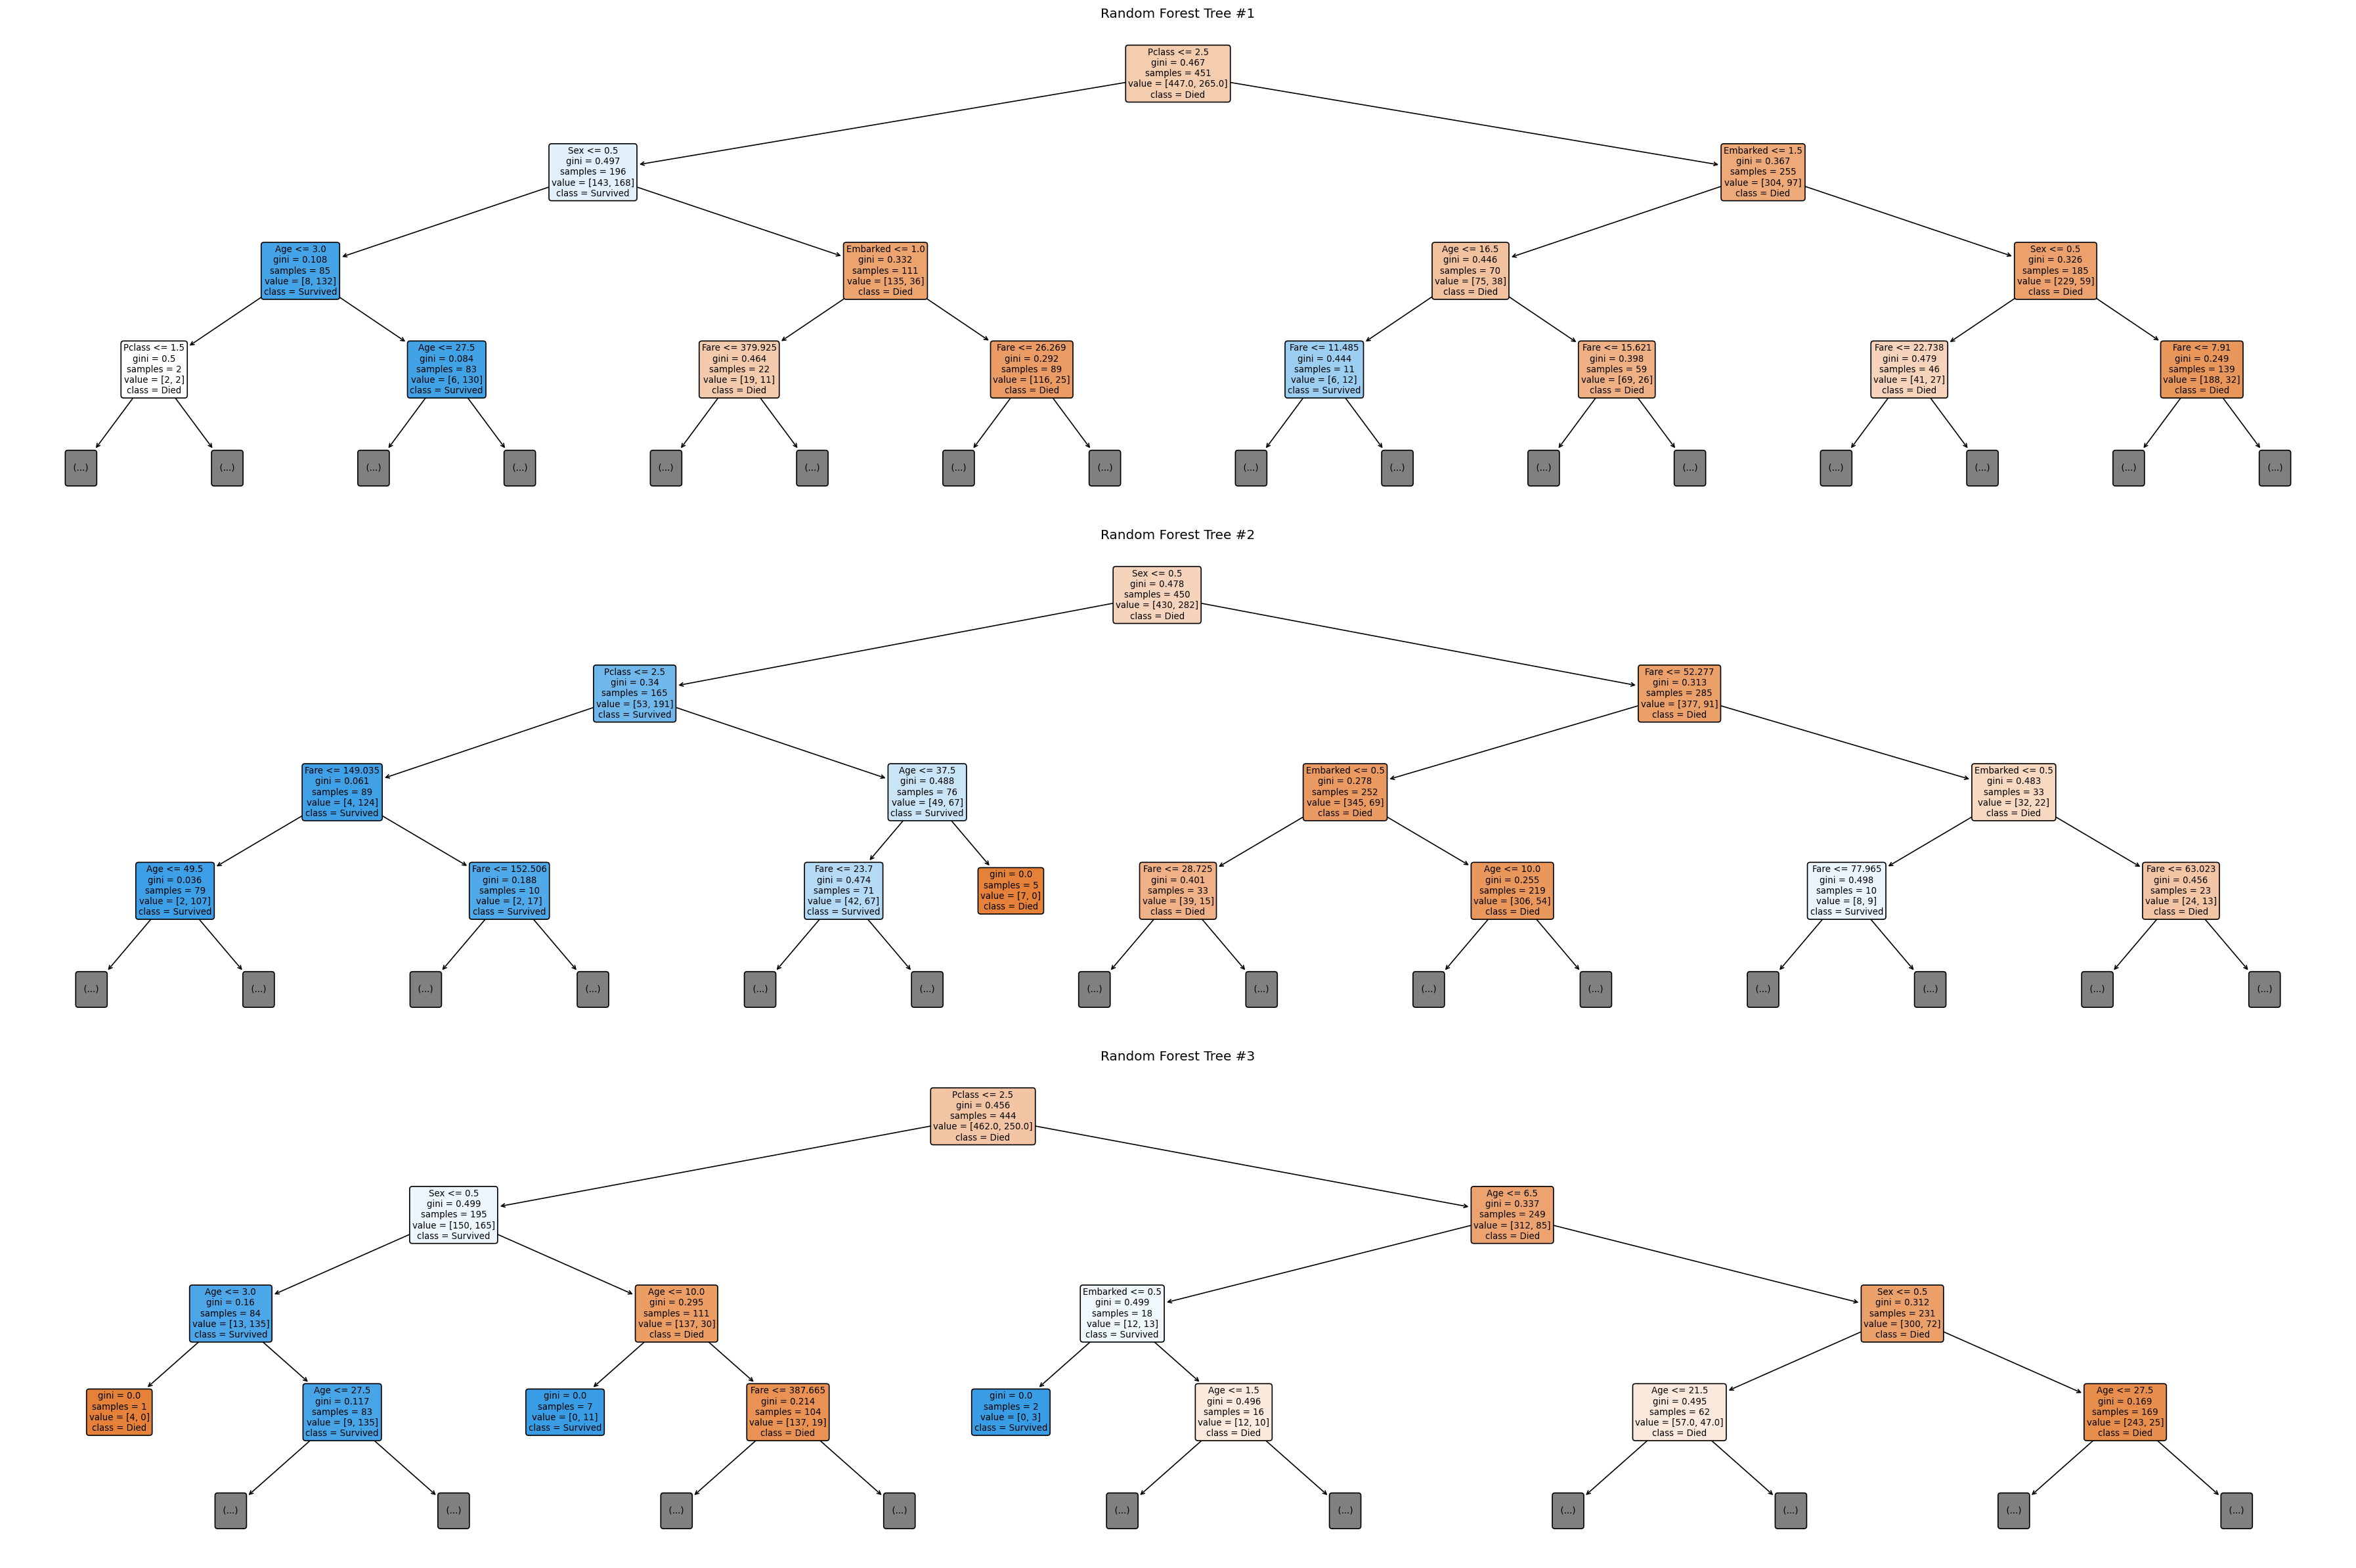

In [7]:
# Implement a Random Forest classifier on the same dataset and compare it to the decision
# tree. Use cross-validation for robustness.

# Import required libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Step 1: Load the Titanic dataset
# ---------------------------------------------------------
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# ---------------------------------------------------------
# Step 2: Select features and target
# ---------------------------------------------------------
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
df = df[features + ['Survived']]

# ---------------------------------------------------------
# Step 3: Handle missing values (NO WARNINGS)
# ---------------------------------------------------------
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# ---------------------------------------------------------
# Step 4: Encode categorical features
# ---------------------------------------------------------
label_encoders = {}
for col in ['Sex', 'Embarked']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# ---------------------------------------------------------
# Step 5: Split features and target
# ---------------------------------------------------------
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# Step 6: Train Decision Tree
# ---------------------------------------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_depth = dt_model.get_depth()

print("--- Decision Tree ---")
print(f"Accuracy: {dt_acc:.2f}")
print(f"Tree Depth: {dt_depth}")
print(f"Leaves: {dt_model.get_n_leaves()}")

# ---------------------------------------------------------
# Step 7: Train Random Forest
# ---------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("\n--- Random Forest ---")
print(f"Accuracy: {rf_acc:.2f}")
print(f"Number of Estimators: {len(rf_model.estimators_)}")
print(f"Average Tree Depth: {sum([t.get_depth() for t in rf_model.estimators_]) / 100:.2f}")

# ---------------------------------------------------------
# Step 8: Cross-validation
# ---------------------------------------------------------
cv_scores_dt = cross_val_score(dt_model, X, y, cv=5)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5)

print("\n--- Cross-validation Results (5-fold) ---")
print(f"Decision Tree CV Accuracy: {cv_scores_dt.mean():.2f} ± {cv_scores_dt.std():.2f}")
print(f"Random Forest CV Accuracy: {cv_scores_rf.mean():.2f} ± {cv_scores_rf.std():.2f}")

# ---------------------------------------------------------
# Feature Importance (Random Forest)
# ---------------------------------------------------------
importances = pd.Series(rf_model.feature_importances_, index=features)

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png")
plt.show()

# ---------------------------------------------------------
# Confusion Matrix — Decision Tree
# ---------------------------------------------------------
cm_dt = confusion_matrix(y_test, dt_pred)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Died', 'Survived'])
disp_dt.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.savefig("confusion_matrix_dt.png")
plt.show()

# ---------------------------------------------------------
# Confusion Matrix — Random Forest
# ---------------------------------------------------------
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Died', 'Survived'])
disp_rf.plot(cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.savefig("confusion_matrix_rf.png")
plt.show()

# ---------------------------------------------------------
# CV Accuracy Distribution Plot
# ---------------------------------------------------------
plt.figure(figsize=(6,4))
sns.kdeplot(cv_scores_dt, fill=True, label="Decision Tree")
sns.kdeplot(cv_scores_rf, fill=True, label="Random Forest")
plt.title("CV Accuracy Distribution")
plt.xlabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("cv_accuracy_distribution.png")
plt.show()

# ---------------------------------------------------------
# Predicted Probabilities Histogram (Random Forest)
# ---------------------------------------------------------
rf_probs = rf_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6,4))
plt.hist(rf_probs[y_test == 1], bins=10, alpha=0.7, label="Survived", color="green")
plt.hist(rf_probs[y_test == 0], bins=10, alpha=0.7, label="Died", color="red")
plt.title("Random Forest: Predicted Probability Distribution")
plt.xlabel("Probability of Survival")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("rf_predicted_probabilities.png")
plt.show()

# ---------------------------------------------------------
# Plot a few decision trees from Random Forest
# ---------------------------------------------------------
n_samples = 3

plt.figure(figsize=(30, 20), dpi=120)

for i in range(n_samples):
    plt.subplot(n_samples, 1, i + 1)
    plot_tree(
        rf_model.estimators_[i],
        feature_names=features,
        class_names=['Died', 'Survived'],
        filled=True,
        rounded=True,
        fontsize=8,
        max_depth=3       # <<< IMPORTANT
    )
    plt.title(f"Random Forest Tree #{i+1}")

plt.tight_layout()
plt.show()
